<a href="https://colab.research.google.com/github/suryansh24-coder/Machine-Learning-Journey/blob/main/Outlier_Detetction_Percentile_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("weight-height.csv")

In [4]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


In [7]:
df.shape

(10000, 3)

In [8]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


In [9]:
import seaborn as sns

/tmp/ipykernel_793/3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

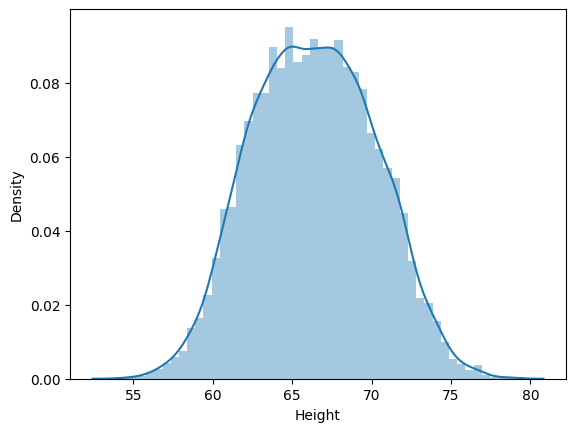

In [10]:
sns.distplot(df['Height'])

<Axes: xlabel='Height'>

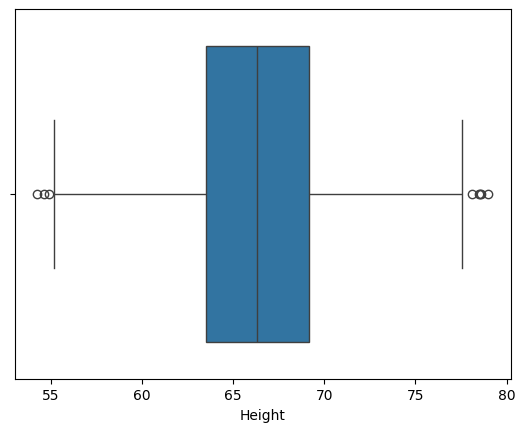

In [12]:
sns.boxplot(df['Height'] , orient='h')

In [13]:
upper_limit = df['Height'].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [15]:
lower_limit = df['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [16]:
df[(df['Height'] >= upper_limit) | (df['Height'] <= lower_limit)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [20]:
new_df = df[(df['Height'] <= upper_limit) & (df['Height'] >= lower_limit)]

In [21]:
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [23]:
new_df['Height'].describe()

,Height
count,9800.000000
mean,66.364366
std,3.645075
min,58.134496
25%,63.577162
50%,66.318070
75%,69.119896
max,74.785714


In [24]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


/tmp/ipykernel_793/4043890578.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Height'] , color='red')
/tmp/ipykernel_793/4043890578.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'] , color='blue')


<Axes: xlabel='Height', ylabel='Density'>

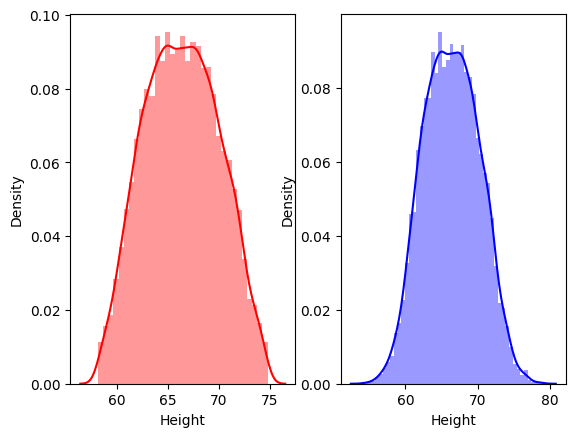

In [26]:
import matplotlib.pyplot as plt
plt.subplot(1,2,1)
sns.distplot(new_df['Height'] , color='red')

plt.subplot(1,2,2)
sns.distplot(df['Height'] , color='blue')

<Axes: xlabel='Height'>

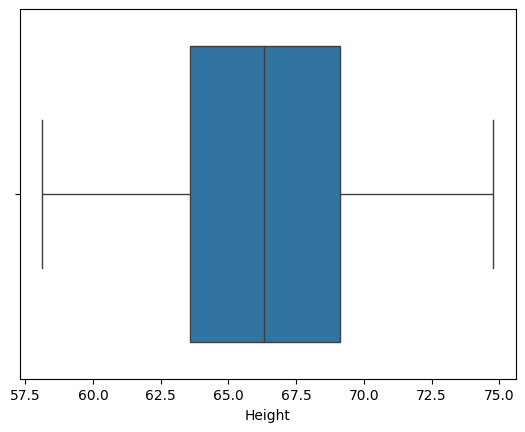

In [28]:
sns.boxplot(new_df['Height'] , orient='h')

In [31]:
# Capping
df['Height'] = np.where(df['Height'] >= upper_limit ,
  upper_limit,
  np.where(df['Height'] <= lower_limit ,
  lower_limit ,
  df['Height']))

In [32]:
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [33]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.366281
std,3.795717
min,58.134412
25%,63.505620
50%,66.318070
75%,69.174262
max,74.785790


In [35]:
df.shape

(10000, 3)

In [36]:
df['Height'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: Height
Non-Null Count  Dtype  
--------------  -----  
10000 non-null  float64
dtypes: float64(1)
memory usage: 78.3 KB


/tmp/ipykernel_793/3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

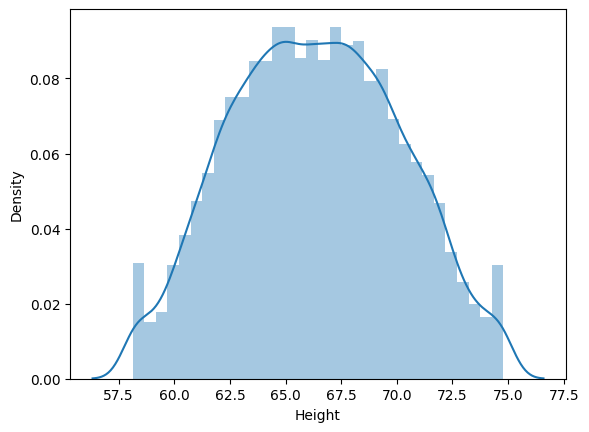

In [37]:
sns.distplot(df['Height'])

<Axes: xlabel='Height'>

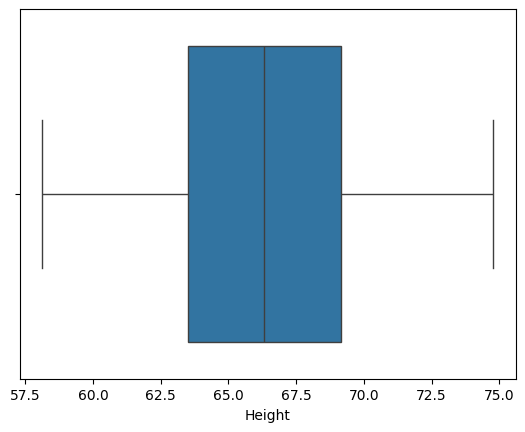

In [38]:
sns.boxplot(df['Height'], orient='h')

/tmp/ipykernel_793/1125578356.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Weight'])


<Axes: xlabel='Weight', ylabel='Density'>

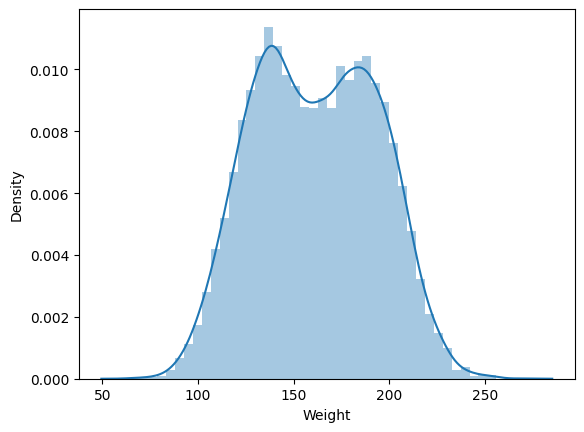

In [40]:
sns.distplot(df['Weight'])

<Axes: xlabel='Weight'>

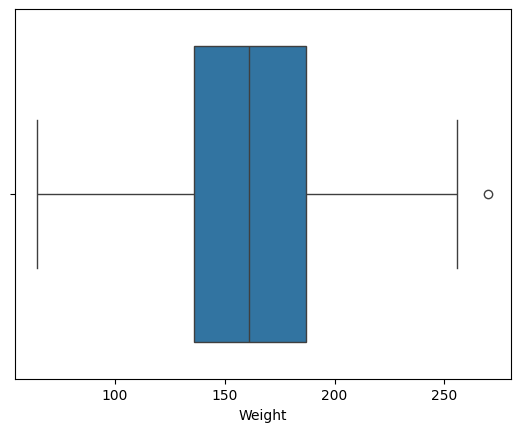

In [41]:
sns.boxplot(df['Weight'], orient='h')

In [42]:
upper_limit2 = df['Weight'].quantile(0.99)
lower_limit2 = df['Weight'].quantile(0.01)
upper_limit2 , lower_limit2

(np.float64(227.43736983602577), np.float64(97.03287365980914))

In [43]:
df[(df['Weight'] >= upper_limit2) | (df['Weight'] <= lower_limit2)]

,Gender,Height,Weight
0,Male,73.847017,241.893563
23,Male,74.785790,228.761781
82,Male,73.826127,237.916736
190,Male,74.785790,235.035419
191,Male,72.571121,230.560535
...,...,...,...
9761,Female,58.134412,90.341784
9775,Female,60.025950,87.035416
9825,Female,58.134412,85.417534
9895,Female,58.134412,93.652957


In [45]:
new_df2 = df[(df['Weight'] <= upper_limit2) & (df['Weight']>= lower_limit2)]

In [46]:
new_df2

,Gender,Height,Weight
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
5,Male,67.253016,152.212156
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [47]:
# Capping
df['Weight'] = np.where(df['Height'] >= upper_limit2 ,
                        upper_limit2 ,
                        np.where(df['Weight'] <= lower_limit2 ,
                                 lower_limit2 ,
                                 df['Weight']))

In [48]:
df['Weight'].describe()

,Weight
count,10000.000000
mean,161.505845
std,31.963723
min,97.032874
25%,135.818051
50%,161.212928
75%,187.169525
max,269.989699


/tmp/ipykernel_793/1125578356.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Weight'])


<Axes: xlabel='Weight', ylabel='Density'>

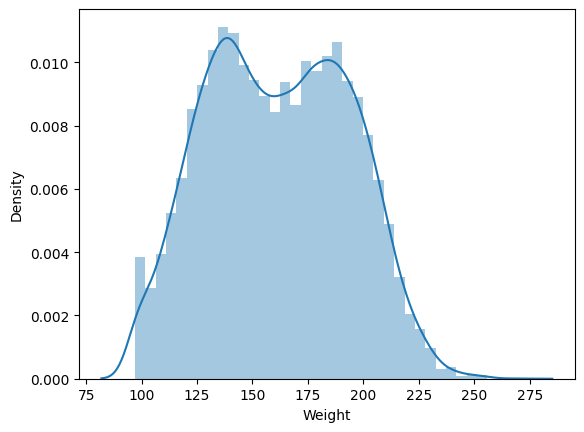

In [49]:
sns.distplot(df['Weight'])

<Axes: xlabel='Weight'>

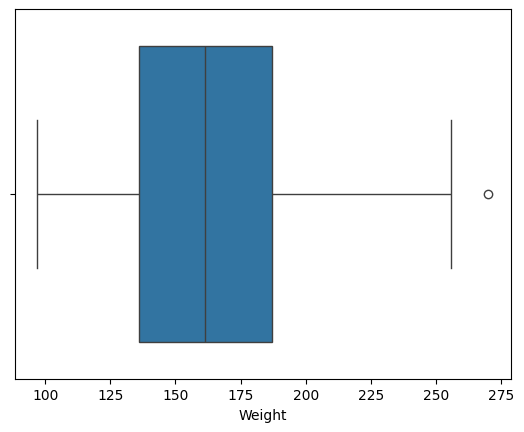

In [50]:
sns.boxplot(df['Weight'] ,orient='h')